In [24]:
import pandas as pd
import json

training_df = pd.read_csv("../data/processed/training_data.csv")

with open("../data/processed/selected_features.json", "r") as file:
    selected_features = json.load(file)

selected_smart_df = training_df[selected_features]

healthy_df = training_df[training_df['failure_within_30_days'] == 0]
failing_soon_df = training_df[training_df['failure_within_30_days'] == 1]

healthy_selected = healthy_df[selected_features]
failing_selected = failing_soon_df[selected_features]

# standard deviation measures how spread out the values are around the mean
healthy_selected_info = healthy_selected.describe()
failing_selected_info = failing_selected.describe()

print(healthy_selected_info)
print(failing_selected_info)



       smart_1_normalized   smart_1_raw  smart_3_normalized   smart_3_raw  \
count        79104.000000  7.910400e+04        78600.000000  78600.000000   
mean            93.100551  4.089390e+07           99.413779   2679.250802   
std             10.246315  7.205860e+07           21.397665   3661.711199   
min             37.000000  0.000000e+00           80.000000      0.000000   
25%             83.000000  0.000000e+00           89.000000      0.000000   
50%            100.000000  0.000000e+00           95.000000    346.000000   
75%            100.000000  6.164222e+07          100.000000   7751.000000   
max            200.000000  4.294967e+09          253.000000  10755.000000   

       smart_4_normalized   smart_4_raw  smart_5_normalized   smart_5_raw  \
count        78600.000000  78600.000000        78825.000000  78825.000000   
mean            99.999084     15.799733           99.652826    298.189661   
std              0.048375     58.665214            4.365256   3011.315636  

## Compare Healthy and Failing-Soon Observations

The selected S.M.A.R.T. features are compared between healthy observations (`failure_within_30_days = 0`) and failing-soon observations (`failure_within_30_days = 1`).

The median is examined first because some of the S.M.A.R.T. features have highly skewed values and large outliers, which can make the mean misleading.

In [38]:
healthy_selected_mean = healthy_selected_info.loc['mean']
failed_selected_mean = failing_selected_info.loc['mean']
healthy_selected_median = healthy_selected_info.loc['50%']
failed_selected_median = failing_selected_info.loc['50%']


print("Healthy selected mean: \n")
print(healthy_selected_mean)
print("\nFailed selected mean: \n")
print(failed_selected_mean)
print("\nHealthy selected median: \n")
print(healthy_selected_median)
print("\nFailed selected median: \n")
print(failed_selected_median)


Healthy selected mean: 

smart_1_normalized      9.310055e+01
smart_1_raw             4.089390e+07
smart_3_normalized      9.941378e+01
smart_3_raw             2.679251e+03
smart_4_normalized      9.999908e+01
smart_4_raw             1.579973e+01
smart_5_normalized      9.965283e+01
smart_5_raw             2.981897e+02
smart_7_normalized      9.543698e+01
smart_7_raw             5.169200e+08
smart_9_normalized      6.214887e+01
smart_9_raw             3.293906e+04
smart_10_normalized     1.000196e+02
smart_12_normalized     9.999751e+01
smart_12_raw            1.472596e+01
smart_192_normalized    9.981523e+01
smart_192_raw           6.747295e+03
smart_193_normalized    9.712664e+01
smart_193_raw           1.247038e+04
smart_194_normalized    7.738235e+01
smart_194_raw           3.357286e+01
smart_197_normalized    9.994821e+01
smart_197_raw           8.198749e+01
smart_198_normalized    9.967553e+01
smart_198_raw           6.526540e+01
smart_199_normalized    1.773432e+02
smart_199_raw

### Initial Findings

Some of the S.M.A.R.T. features have different values between healthy and failing-soon observations.

- `smart_5_raw` has a higher mean and median for failing-soon observations.
- `smart_197_raw` also has a higher mean and median for failing-soon observations.
- `smart_198_raw` has a much higher mean for failing-soon observations, but the median stays at 0.
- `smart_9_raw` and `smart_193_raw` also have higher median values for failing-soon observations.

## Feature Distributions

I will compare some of the S.M.A.R.T. features that showed differences between healthy and failing-soon observations.

<Axes: >

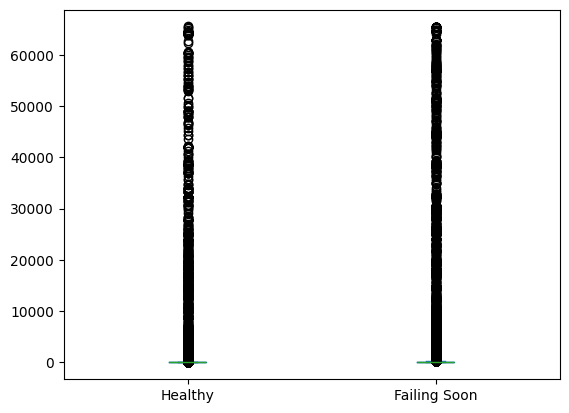

In [47]:
smart_5_comparison = pd.DataFrame({
    "Healthy": healthy_selected["smart_5_raw"],
    "Failing Soon": failing_selected["smart_5_raw"]
})

smart_5_comparison.plot.box()

<Axes: ylabel='Frequency'>

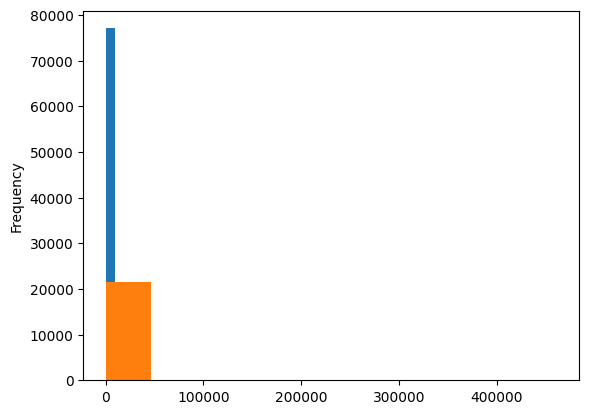

In [49]:
healthy_selected["smart_197_raw"].plot.hist()
failing_selected["smart_197_raw"].plot.hist()

## Summary

The analysis showed that some S.M.A.R.T. features have different values for healthy and failing-soon observations.

Features such as `smart_5_raw`, `smart_197_raw`, `smart_198_raw`, and `smart_193_raw` showed big differences between the two groups.

Some features also had large outliers and skewed distributions, which caused the mean to be much higher than the median.

These results show that some S.M.A.R.T. features may contain useful information for predicting drive failure and should be tested when training the models.